In [1]:
import pandas as pd
import sqlite3
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# Predicting Freight Cost

**Objective:** Predict freight cost for a vendor invoice using quantity and dollars, to improve cost forecasting, budgeting, and vendor negotiation.

- Freight is a non-trivial component of landed cost.
- Poor freight estimates distort margin and inventory planning.
- Automating freight estimation helps procurement teams forecast true cost before invoice arrival.

In [2]:
# Connect to the inventory SQLite database
db_path = Path.cwd() / "Data" / "inventory.db"
if not db_path.exists():
    db_path = Path.cwd().parent / "Data" / "inventory.db"
if not db_path.exists():
    raise FileNotFoundError("Could not find Data/inventory.db. Run this notebook from the project root or notebooks folder.")

conn = sqlite3.connect(db_path)

# Confirm available tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    conn,
)
tables

,name
0,begin_inventory
1,end_inventory
2,purchase_prices
3,purchases
4,vendor_invoice


In [3]:
for table in tables['name']:
    print('Table name',table)
    df = pd.read_sql_query(f"select * from {table} limit 5", conn)
    display(df)

Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [4]:
# Load data needed for freight-cost analysis
vendor_invoice = pd.read_sql_query("SELECT * FROM vendor_invoice;", conn)
begin_inventory = pd.read_sql_query("SELECT * FROM begin_inventory;", conn)
end_inventory = pd.read_sql_query("SELECT * FROM end_inventory;", conn)

print("Vendor invoice shape:", vendor_invoice.shape)
print("Beginning inventory shape:", begin_inventory.shape)
print("Ending inventory shape:", end_inventory.shape)

vendor_invoice.head() 

Vendor invoice shape: (5543, 10)
Beginning inventory shape: (206529, 9)
Ending inventory shape: (224489, 9)


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [5]:
vendor_invoice[['Quantity', 'Freight', 'Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


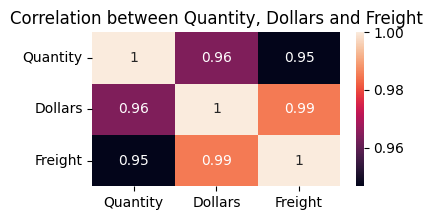

In [6]:
plt.figure(figsize=(4, 2))
sns.heatmap(vendor_invoice[['Quantity', 'Dollars', 'Freight']].corr(), annot=True)
plt.title('Correlation between Quantity, Dollars and Freight')
plt.show()



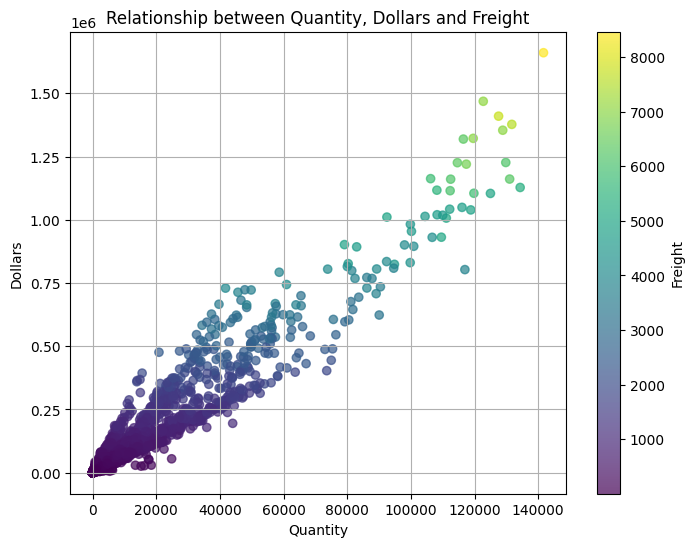

In [7]:
plot_data = vendor_invoice[['Quantity', 'Dollars', 'Freight']].dropna()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    plot_data['Quantity'],
    plot_data['Dollars'],
    c=plot_data['Freight'],
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(scatter, label='Freight')
plt.xlabel('Quantity')
plt.ylabel('Dollars')
plt.title('Relationship between Quantity, Dollars and Freight')
plt.grid(True)
plt.show()

In [8]:
# Create an interpretable freight-per-unit metric.
vendor_invoice['freight_per_unit'] = vendor_invoice['Freight'] / vendor_invoice['Quantity']

In [9]:
low_quantity = vendor_invoice['Quantity'].quantile(0.25)
high_quantity = vendor_invoice['Quantity'].quantile(0.75)

In [10]:
high_quantity

np.float64(5100.5)

In [11]:
low_quantity

np.float64(83.0)

In [12]:
vendor_invoice.loc[vendor_invoice['Quantity']<low_quantity, 'freight_per_unit'].mean()

np.float64(0.09489854253138316)

In [13]:
vendor_invoice.loc[vendor_invoice['Quantity']>high_quantity, 'freight_per_unit'].mean()

np.float64(0.049077654690759046)

In [14]:
# Keep only the columns needed for modeling and verify they are complete.
model_data = vendor_invoice[['Quantity', 'Dollars', 'Freight']].dropna()

X = model_data[['Quantity', 'Dollars']]
y = model_data['Freight']

print(f'Modeling rows: {len(model_data):,}')
print(f'Missing values after cleanup: {model_data.isna().sum().sum()}')

Modeling rows: 5,543
Missing values after cleanup: 0


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    root_mean_squared_error = None

In [18]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
    ),
}

for model in models.values():
    model.fit(x_train, y_train)

In [ ]:
def evaluate_model(model, x_test, y_test, model_name):
    preds = model.predict(x_test)

    mae = mean_absolute_error(y_test, preds)
    if root_mean_squared_error is not None:
        rmse = root_mean_squared_error(y_test, preds)
    else:
        rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
    }

results_df = pd.DataFrame(
    evaluate_model(model, x_test, y_test, model_name)
    for model_name, model in models.items()
).sort_values('RMSE')

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,24.459181,124.428785,0.970020
2,Random Forest Regressor,27.645809,138.621173,0.962791
1,Decision Tree Regressor,33.868418,182.500765,0.935505


In [21]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f'Best model: {best_model_name}')
print(f"Test RMSE: {results_df.iloc[0]['RMSE']:.2f}")
print(f"Test R2: {results_df.iloc[0]['R2']:.2%}")

Best model: Linear Regression
Test RMSE: 124.43
Test R2: 97.00%


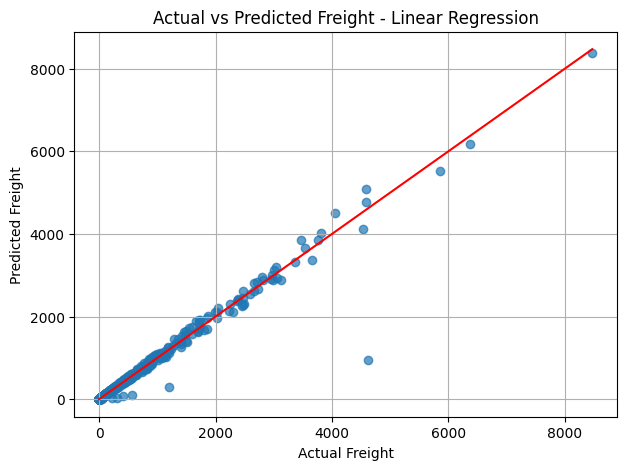

In [22]:
test_predictions = best_model.predict(x_test)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, test_predictions, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
)
plt.xlabel('Actual Freight')
plt.ylabel('Predicted Freight')
plt.title(f'Actual vs Predicted Freight - {best_model_name}')
plt.grid(True)
plt.show()

In [23]:
def predict_freight_cost(quantity, dollars):
    invoice = pd.DataFrame(
        {
            'Quantity': [quantity],
            'Dollars': [dollars],
        }
    )
    return float(best_model.predict(invoice)[0])


# Direct test input values for the model.
# You can change only these two values to test another invoice.
test_quantity = 423
test_dollars = 4765.45

predicted_freight = predict_freight_cost(test_quantity, test_dollars)

print('Model test input:')
print(f'Quantity: {test_quantity:,.0f}')
print(f'Dollars : ${test_dollars:,.2f}')
print(f'Predicted Freight Cost: ${predicted_freight:,.2f}')

Model test input:
Quantity: 423
Dollars : $4,765.45
Predicted Freight Cost: $29.61


## Conclusion

The freight-cost prediction problem is solved with a supervised regression workflow. Quantity and invoice dollars are strong predictors of freight cost, and the selected model is chosen by the lowest test RMSE. The `predict_freight_cost` function can now estimate freight for a new vendor invoice before the final invoice arrives.
